# Solución de problemas con pipelines - Preprocesamiento y búsqueda de hiperparámetros

En este tutorial aprenderás cómo crear pipelines para ejecutar todo el proceso de machine learning para el entrenamiento de un modelo de árboles de decisión. En ese sentido, realizarás la búsqueda de hiperparámetros y evaluarás el mejor modelo usando métricas de rendimiento para un problema de clasificación. Específicamente, verás cómo realizar los siguientes procesos:

1. Importar las librerías requeridas.
2. Cargar un conjunto de datos.
3. Explorar el conjunto de datos.
4. Definir los pasos del preprocesamiento de datos.
5. Realizar la búsqueda de hiperparámetros mediante un pipeline.
6. Evaluar el mejor modelo resultante.
7. Revisar bajoajuste y sobreajuste

En este tutorial seguiremos utilizando el conjunto de datos correspondiente a la compra de seguros de viaje. En este problema queremos predecir si una persona va a comprar un seguro de viaje dependiendo de factores como su edad, salario, educación, entre otros.

## 1. Importación de librerías requeridas

Importaremos las librerías `pandas`, `numpy` y `scikit-learn`. En particular, usaremos las siguientes clases y funciones para construir el pipeline, así como entrenar y evaluar el modelo de árboles de decisión:

* `Pipeline()`: clase para construir el pipeline.
* `SimpleImputer()`: clase para realizar la imputación de datos.
* `ColumnTransformer()`: clase para realizar transformaciones por columnas.
* `StandardScaler()` y `MinMaxScaler()`: clases para realizar la estandarización.
* `OneHotEncoder()`: clase para realizar la codificación OneHot.
* `DecisionTreeClassifier()`: clase para crear el modelo de árbol de decisión.
* `classification_report()`: función para obtener un reporte con las métricas de rendimiento por clase.
* `ConfusionMatrixDisplay()`: clase para graficar la matriz de confusión.
* `accuracy_score()`: función para obtener la exactitud en un modelo de clasificación.
* `precision_score()`: función para obtener la precisión en un modelo de clasificación.
* `recall_score()`: función para obtener la sensibilidad en un modelo de clasificación.
* `f1_score()`: función para obtener la métrica F1 en un modelo de clasificación.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from importlib.metadata import version

print(f"Versión de Pandas: {version('pandas')}")
print(f"Versión de Scikit-learn: {version('scikit-learn')}")
print(f"Versión de Numpy: {version('numpy')}")
print(f"Versión de Matplotlib: {version('matplotlib')}")

Versión de Pandas: 2.2.3
Versión de Scikit-learn: 1.6.1
Versión de Numpy: 1.25.2
Versión de Matplotlib: 3.10.0


## 2. Carga de datos

Realizaremos la carga de datos usando la función de Pandas `read_csv()`, especificando la ruta y el separador del archivo:

In [2]:
data_raw = pd.read_csv('data/TravelInsurancePrediction.csv', sep=',')

Veamos los primeros datos del conjunto utilizando `head()`:

In [3]:
data_raw.head()

,Index,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,0,31.0,Government Sector,Yes,400000.0,6.0,1.0,No,No,0
1,1,31.0,Private Sector/Self Employed,Yes,1250000.0,7.0,0.0,No,No,0
2,2,34.0,Private Sector/Self Employed,Yes,500000.0,4.0,1.0,No,No,1
3,3,28.0,Private Sector/Self Employed,Yes,700000.0,3.0,1.0,No,No,0
4,4,28.0,Private Sector/Self Employed,Yes,700000.0,8.0,1.0,Yes,No,0


Como puedes observar, nuestro conjunto de datos contiene cinco variables categóricas: `Employment Type`, `GraduateOrNot`, `ChronicDiseases`, `FrequentFlyer` y `EverTravelledAbroad`.

## 3. Exploración del conjunto de datos

Utilizaremos `data_raw.describe()` para obtener una descripción de las variables numéricas del conjunto de datos. Ten en cuenta que esta función también incluye variables categóricas con clases numéricas:

In [4]:
data_raw.describe()

,Index,Age,AnnualIncome,FamilyMembers,ChronicDiseases,TravelInsurance
count,1987.000000,1939.000000,1.937000e+03,1931.000000,1940.000000,1987.000000
mean,993.000000,29.670449,9.358286e+05,4.767996,0.278866,0.357323
std,573.741812,2.910996,3.762435e+05,1.614709,0.448557,0.479332
min,0.000000,25.000000,3.000000e+05,2.000000,0.000000,0.000000
25%,496.500000,28.000000,6.000000e+05,4.000000,0.000000,0.000000
50%,993.000000,29.000000,9.000000e+05,5.000000,0.000000,0.000000
75%,1489.500000,32.000000,1.250000e+06,6.000000,1.000000,1.000000
max,1986.000000,35.000000,1.800000e+06,9.000000,1.000000,1.000000


## 4. Definición de pasos del preprocesamiento de datos

Primero vamos a definir la variable `data` para almacenar un conjunto de datos modificado, utilizando el método `copy()`:

In [5]:
data = data_raw.copy()

### Eliminación de variables poco relevantes

Este conjunto de datos solo tiene una variable poco relevante para predecir si el cliente va a comprar un seguro de viajes: `Index`. Haciendo uso de la función `drop()`, eliminaremos esta variable del DataFrame:

In [6]:
data = data.drop('Index', axis=1)

### Tratamiento de nulos y duplicados

Veremos si hay duplicados utilizando `duplicated().sum()`:

In [7]:
data.duplicated().sum()

486

Podemos tratar directamente los datos duplicados antes de entrar al pipeline mediante la función `drop_duplicates()` de Pandas: 

In [8]:
data = data.drop_duplicates()

Adicionalmente, revisaremos si nuestros datos contienen datos nulos usando `isna().sum()`:

In [9]:
data.isna().sum()

Age                    48
Employment Type        83
GraduateOrNot          65
AnnualIncome           48
FamilyMembers          51
ChronicDiseases        47
FrequentFlyer          90
EverTravelledAbroad    92
TravelInsurance         0
dtype: int64

En vez de eliminar estos datos, realizaremos una imputación para reemplazar los valores nulos por valores como la media, mediana, entre otros. En ese sentido, definiremos dos objetos de la clase `SimpleImputer()`, especificando que reemplazaremos los valores nulos por el valor más frecuente (para las variables categóricas), para las numéricas usaremos gridSearch para encontrar la mejor estrategia:

In [10]:
cat_imputer = SimpleImputer(strategy='most_frequent')
num_imputer = SimpleImputer()

Unificaremos estos objetos en un solo paso del pipeline mediante un objeto de la clase `ColumnTransformer()`, especificando dos listas con los nombres de las variables numéricas y categóricas: 


**Nota:** por defecto, la clase `ColumnTransformer()` va a agregar el nombre del paso ejecutado a cada variable causando que, por ejemplo `AnnualIncome` se pase a llamar `num_AnnualIncome` o `GraduateOrNot` se vuelva `cat_GraduateOrNot`. Esto causa que los pasos siguientes puedan fallar al no encontrar los nombres exactos de las columnas. Por lo que para evitar este comportamiento agregamos el parámetro `verbose_feature_names_out=False`

In [11]:
# Variables Age, AnnualIncome, FamilyMembers
numeric_features = ["Age", "AnnualIncome", "FamilyMembers"]
# Variables Employment Type, GraduateOrNot, ChronicDiseases, FrequentFlyer, EverTravelledAbroad
categorical_features = ["Employment Type", "GraduateOrNot", "ChronicDiseases", "FrequentFlyer", "EverTravelledAbroad"]

imputer = ColumnTransformer(
    transformers=[
        ("num", num_imputer, numeric_features),
        ("cat", cat_imputer, categorical_features)
    ],
    verbose_feature_names_out=False
)

### Transformación de variables categóricas

Como la implementación de `sklearn` necesita que todos los valores de las variables sean numéricos, incluiremos una codificación OneHot dentro del pipeline mediante un objeto de la clase `OneHotEncoder()`, especificando que la salida no necesita manejo especial por dispersión con `sparse_output=False`:

In [12]:
encoder = OneHotEncoder(sparse_output=False)

### Estandarización de variables numéricas

Igualmente, el modelo de árboles de decisión no necesita estandarizar las variables para realizar las particiones. Sin embargo, incluiremos un paso de estandarización por completitud de nuestro pipeline de preprocesamiento, haciendo uso de un objeto de la clase `StandardScaler()`: 

In [13]:
scaler = StandardScaler()

Ten en cuenta que el paso de imputación retorna un arreglo de `numpy` con un orden diferente: las variables numéricas están agrupadas en los primeros índices, seguidas de las variables categóricas. Utilizaremos un objeto de la clase `ColumnTransformer()` para especificar el tipo de transformación que se usará con cada conjunto de variables, teniendo en cuenta este nuevo orden:

In [14]:
transformer = ColumnTransformer(
    transformers=[
        ("num", scaler, numeric_features),
        ("cat", encoder, categorical_features)
    ],
    verbose_feature_names_out=False
)

### División de datos

Ahora dividiremos el conjunto de datos resultante en un conjunto de entrenamiento y uno de pruebas mediante la función `train_test_split()`. Usaremos el 80% de los datos para el entrenamiento y el 20% restante para las pruebas:

In [15]:
train, test = train_test_split(data, test_size=0.2, random_state=9)
train.head()

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
857,28.0,Government Sector,Yes,600000.0,3.0,0.0,No,No,1
783,29.0,Private Sector/Self Employed,Yes,1100000.0,7.0,0.0,NaN,No,0
1326,34.0,Private Sector/Self Employed,Yes,700000.0,5.0,0.0,No,No,0
1780,31.0,Private Sector/Self Employed,Yes,950000.0,NaN,0.0,Yes,No,0
1424,31.0,Government Sector,Yes,400000.0,9.0,0.0,No,No,0


Además, separaremos la variable objetivo `TravelInsurance` de las variables descriptoras:

In [16]:
x_train = train.drop(['TravelInsurance'],axis=1)
y_train = train['TravelInsurance']

## 5. Búsqueda de hiperparámetros con un pipeline

Con el conjunto de datos modificado, crearemos un objeto de la clase `DecisionTreeClassifier()` que será nuestro modelo base para realizar la búsqueda exhaustiva de hiperparámetros:

In [17]:
decision_tree = DecisionTreeClassifier(random_state=0)

### Creación del pipeline

Siguiendo el concepto de transformadores y estimadores de `scikit-learn`, podemos incluir el preprocesamiento como los transformadores y el modelo como el estimador. Definiremos la secuencia de pasos que aplicaremos sobre el conjunto de datos utilizando tuplas de la forma `(nombre, objeto)`:

In [18]:
steps = [
    ("imputer", imputer),
    ("transformer", transformer),
    ("model", decision_tree),
]

Con la secuencia de pasos definida, crearemos un objeto de la clase `Pipeline()` para realizar la búsqueda:

In [19]:
pipeline = Pipeline(steps).set_output(transform="pandas")
pipeline

Pipeline(steps=[('imputer',
                 ColumnTransformer(transformers=[('num', SimpleImputer(),
                                                  ['Age', 'AnnualIncome',
                                                   'FamilyMembers']),
                                                 ('cat',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['Employment Type',
                                                   'GraduateOrNot',
                                                   'ChronicDiseases',
                                                   'FrequentFlyer',
                                                   'EverTravelledAbroad'])],
                                   verbose_feature_names_out=False)),
                ('transformer',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'AnnualIncome',
                                                   'FamilyMembers']),
                                                 ('cat',
                                                  OneHotEncoder(sparse_output=False),
                                                  ['Employment Type',
                                                   'GraduateOrNot',
                                                   'ChronicDiseases',
                                                   'FrequentFlyer',
                                                   'EverTravelledAbroad'])],
                                   verbose_feature_names_out=False)),
                ('model', DecisionTreeClassifier(random_state=0))])

### Búsqueda de hiperparámetros

Uno de los beneficios de los pipelines es que podemos incluir otros parámetros diferentes a los del modelo dentro de la búsqueda de hiperparámetros. En ese sentido, utilizaremos los siguientes parámetros para realizar la búsqueda:

* **Estrategia de imputación (variables numéricas)**: utilizaremos la media y la mediana.
* **Estrategia de estandarización**: utilizaremos un objeto de la clase `StandardScaler()` y un objeto de la clase `MinMaxScaler()`.
* `criterion`: el criterio de pureza, que determina la calidad de una división. Utilizaremos dos de los más populares: la entropía y GINI.
* `max_depth`: la profundidad máxima del árbol. Este hiperparámetro se utiliza para el control de la complejidad del modelo.
* `min_samples_split`: número mínimo de datos necesarios en un nodo para poder definir una división.

Para especificar qué parámetro vamos a modificar en cada paso, utilizaremos la estructura `<paso>__<parámetro>` para definir las llaves del diccionario. En el caso de los `ColumnTransformer()`, que usan varios objetos en paralelo, utilizaremos la estructura `<transformer>__<objeto>__<parámetro>`. Incluso, podemos modificar los propios objetos del `ColumnTransformer()` mediante la estructura `<transformer>__<objeto>`:

In [20]:
param_grid = {
    # Paso de imputación
    'imputer__num__strategy': ['mean', 'median'],
    # Paso de transformación
    'transformer__num': [StandardScaler(), MinMaxScaler()],
    # Paso de modelado
    'model__criterion': ['entropy', 'gini'],
    'model__max_depth': [4, 6],
    'model__min_samples_split': [2, 3]
}

Al igual que en la búsqueda únicamente sobre los parámetros del modelo, definiremos un objeto de la clase `KFold()` para realizar la validación cruzada con 5 subconjuntos de datos:

In [21]:
kfold = KFold(n_splits=5, shuffle=True, random_state=0)

Finalmente, definiremos la búsqueda con un objeto de la clase `GridSearchCV()` usando el pipeline `pipeline`, el espacio de búsqueda `param_grid` y la técnica de validación cruzada `kfold`:

In [22]:
grid = GridSearchCV(pipeline, param_grid, cv=kfold)

Ejecutaremos la búsqueda sobre el conjunto de entrenamiento original, que será modificado por el pipeline dependiendo de los pasos definidos para cada iteración:

In [23]:
grid.fit(x_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('imputer',
                                        ColumnTransformer(transformers=[('num',
                                                                         SimpleImputer(),
                                                                         ['Age',
                                                                          'AnnualIncome',
                                                                          'FamilyMembers']),
                                                                        ('cat',
                                                                         SimpleImputer(strategy='most_frequent'),
                                                                         ['Employment '
                                                                          'Type',
                                                                          'GraduateOrNot',
                                                                          'ChronicDiseases',
                                                                          'FrequentFlyer',
                                                                          'EverTravelledAbroad'])],
                                                          verbose_featur...
                                                                          'GraduateOrNot',
                                                                          'ChronicDiseases',
                                                                          'FrequentFlyer',
                                                                          'EverTravelledAbroad'])],
                                                          verbose_feature_names_out=False)),
                                       ('model',
                                        DecisionTreeClassifier(random_state=0))]),
             param_grid={'imputer__num__strategy': ['mean', 'median'],
                         'model__criterion': ['entropy', 'gini'],
                         'model__max_depth': [4, 6],
                         'model__min_samples_split': [2, 3],
                         'transformer__num': [StandardScaler(),
                                              MinMaxScaler()]})

Ahora obtendremos los mejores valores de los hiperparámetros usando `grid.best_params_`:

In [24]:
print("Mejores parámetros: {}".format(grid.best_params_))

Mejores parámetros: {'imputer__num__strategy': 'mean', 'model__criterion': 'entropy', 'model__max_depth': 4, 'model__min_samples_split': 2, 'transformer__num': StandardScaler()}


Como puedes ver, en términos de preprocesamiento se utiliza la media para la imputación y un `StandardScaler()` para la estandarización. Para el mejor modelo, se utiliza la entropía como criterio de pureza, una profundidad máxima de 4 y un mínimo de 2 datos para realizar una división. Almacenaremos el mejor pipeline completo utilizando `grid.best_estimator_`:

In [25]:
mejor_pipeline = grid.best_estimator_
mejor_pipeline

Pipeline(steps=[('imputer',
                 ColumnTransformer(transformers=[('num', SimpleImputer(),
                                                  ['Age', 'AnnualIncome',
                                                   'FamilyMembers']),
                                                 ('cat',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['Employment Type',
                                                   'GraduateOrNot',
                                                   'ChronicDiseases',
                                                   'FrequentFlyer',
                                                   'EverTravelledAbroad'])],
                                   verbose_feature_names_out=False)),
                ('transformer',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'AnnualIncome',
                                                   'FamilyMembers']),
                                                 ('cat',
                                                  OneHotEncoder(sparse_output=False),
                                                  ['Employment Type',
                                                   'GraduateOrNot',
                                                   'ChronicDiseases',
                                                   'FrequentFlyer',
                                                   'EverTravelledAbroad'])],
                                   verbose_feature_names_out=False)),
                ('model',
                 DecisionTreeClassifier(criterion='entropy', max_depth=4,
                                        random_state=0))])

In [26]:
rf_model = mejor_pipeline.named_steps["model"]
feature_names = mejor_pipeline.named_steps["transformer"].get_feature_names_out()
importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
importances


AnnualIncome                                    0.636082
FamilyMembers                                   0.211247
Age                                             0.115149
GraduateOrNot_Yes                               0.016946
GraduateOrNot_No                                0.013893
EverTravelledAbroad_Yes                         0.006682
Employment Type_Government Sector               0.000000
Employment Type_Private Sector/Self Employed    0.000000
ChronicDiseases_0.0                             0.000000
ChronicDiseases_1.0                             0.000000
FrequentFlyer_No                                0.000000
FrequentFlyer_Yes                               0.000000
EverTravelledAbroad_No                          0.000000
dtype: float64

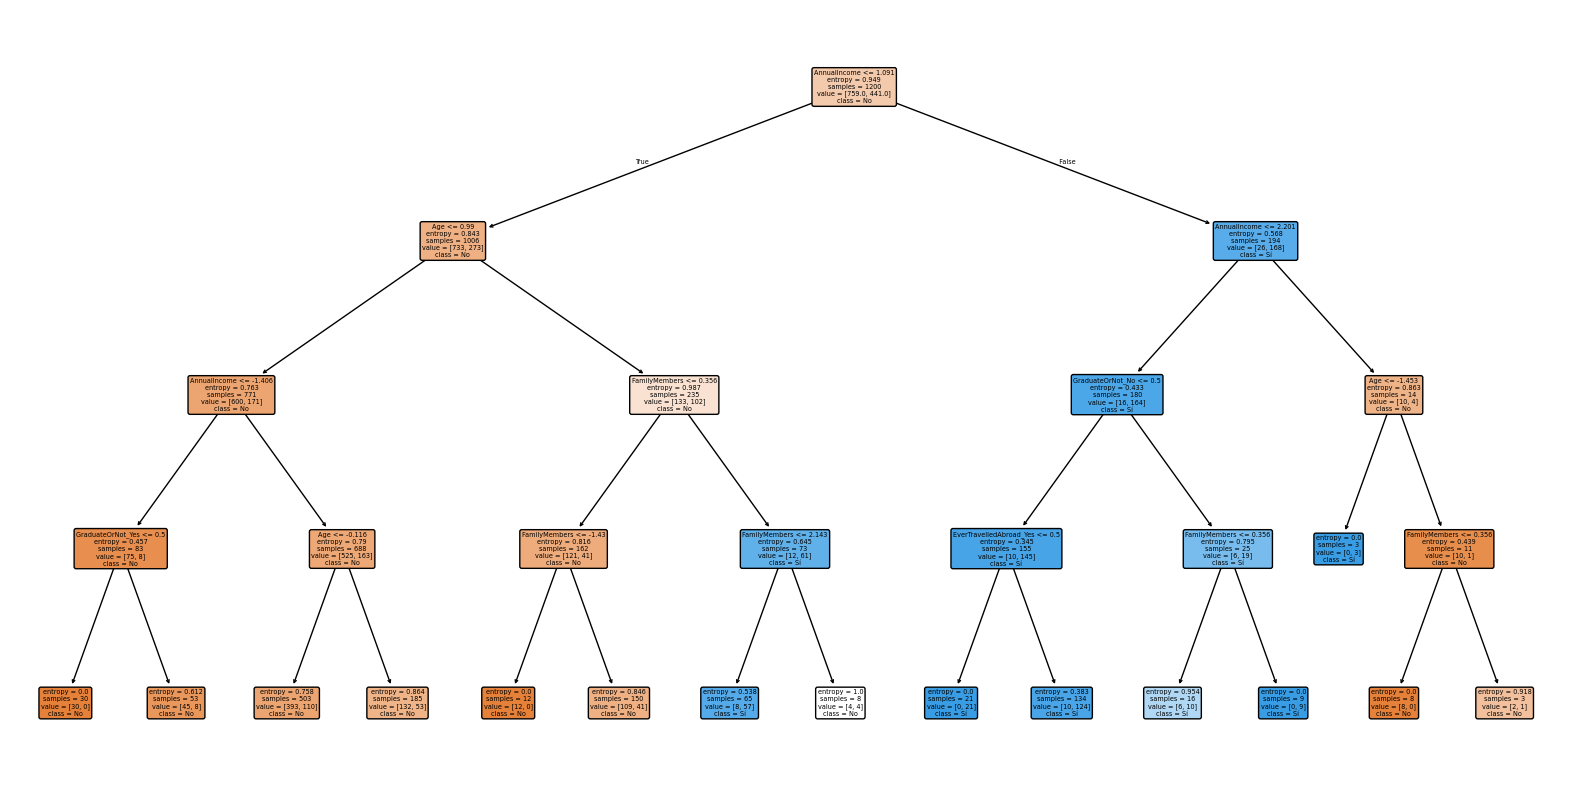

In [27]:


import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    rf_model,
    feature_names=feature_names,
    class_names=["No", "Sí"],   # ajusta según tus clases
    filled=True,
    rounded=True
)
plt.show()

#plt.figure(figsize=(25,10))
#tree = plot_tree(mejor_pipeline, feature_names=x_train.columns, class_names=['No','Yes'], filled=True, fontsize=9)

## Probando el funcionamiento del Pipeline

El pipeline que tenemos en la variable `mejor_pipeline` incluye tanto los pasos de preprocesamiento de los datos como el árbol de decisión. Mientras que esto resulta útil para facilitar la predicción de datos, puede ocurrir que los mismos datos que estamos usando aquí los necesitemos para algún paso _diferente_ a la predicción del pipeline, por ejemplo, para analizar los datos preprocesados, enviarlos a varios modelos diferentes, o guardarlos para proyectos futuros.

Un pipeline, como secuencia de pasos, nos permite también ejecutarlo por partes. En el siguiente ejemplo, usamos el mejor pipeline por partes para preprocesar con las transformaciones y predecir con el modelo de forma separada:

Nuestro pipeline tiene 3 pasos, imputar, transformar y predecir. Luego, podemos usar los primeros dos pasos para obtener los datos transformados, esto por medio de la sintaxis de Python para obtener partes de listas o _slicing_. Para esto, usamos `mejor_pipeline[0:2]` y la función `transform()`:

In [28]:
x_train_transformed = mejor_pipeline[:2].transform(x_train)
x_train_transformed.head(3)

,Age,AnnualIncome,FamilyMembers,Employment Type_Government Sector,Employment Type_Private Sector/Self Employed,GraduateOrNot_No,GraduateOrNot_Yes,ChronicDiseases_0.0,ChronicDiseases_1.0,FrequentFlyer_No,FrequentFlyer_Yes,EverTravelledAbroad_No,EverTravelledAbroad_Yes
857,-0.580701,-0.920712,-1.132278,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
783,-0.231679,0.466695,1.249410,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
1326,1.513433,-0.643230,0.058566,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0


Y podemos usar el último paso del pipeline con `mejor_pipeline[2]`, que corresponde al Árbol de decisión, para predecir sobre los datos transformados usando la función `predict()`:

In [29]:
y_train_pred = mejor_pipeline[2].predict(x_train_transformed)
y_train_pred

array([0, 0, 0, ..., 0, 1, 1])

Estas predicciones provienen del conjunto de datos de entrenamiento, por lo que las aprovecharemos más adelante para revisar sobreajuste

## 6. Evaluación del mejor modelo

Empezaremos separando la variable objetivo de las variables descriptoras en el conjunto de pruebas:

In [30]:
x_test = test.drop(['TravelInsurance'],axis=1)
y_test = test['TravelInsurance']

Incluso con los pasos de preprocesamiento integrados a nuestro modelo, podemos realizar predicciones sobre el conjunto de pruebas directamente mediante la función `predict()`:

In [31]:
y_test_pred = mejor_pipeline.predict(x_test)

Ahora utilizaremos la función `plot_confusion_matrix()` para generar un mapa de calor con los valores de la matriz de confusión:

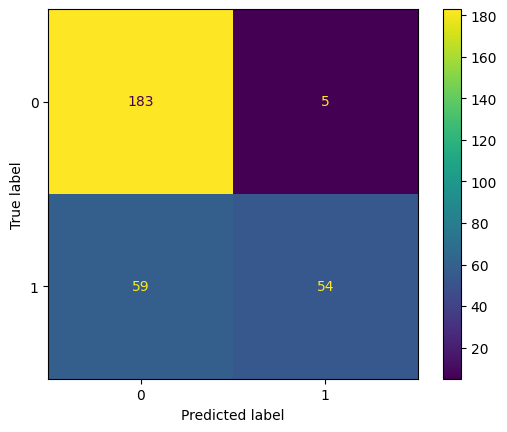

In [32]:
ConfusionMatrixDisplay.from_estimator(mejor_pipeline, x_test, y_test)
plt.show()

Como puedes observar, el modelo tiene el mismo comportamiento que el encontrado en la primera parte, con los mismos resultados de clasificación para ambas clases. Específicamente, podemos observar las métricas de desempeño usando `classification_report()`:

In [33]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.76      0.97      0.85       188
           1       0.92      0.48      0.63       113

    accuracy                           0.79       301
   macro avg       0.84      0.73      0.74       301
weighted avg       0.82      0.79      0.77       301



En este modelo se tienen valores altos en la sensibilidad de la clase 0. Como la clase 1 no tiene tanta representación, se tiene una sensibilidad bastante baja, aunque la precisión tiene un valor alto. Este valor de precisión indica que de los datos que el árbol clasifica en la clase 1 la mayoría realmente pertenecen a esta clase.

## 7. Revisión de sobreajuste

Cuando entrenamos modelos de aprendizaje, el conjunto de datos de prueba nos permite saber qué tan bien se desempeña el modelo con datos que no conoce. Sin embargo, hay que tener cuidado con 2 situaciones perjudiciales que llamaremos bajoajuste o _underfitting_, y sobreajuste o _overfitting_.

A grandes rasgos, consideramos que un modelo está bajoajustado si su rendimiento en general es bajo; y un modelo como sobreajustado si su capacidad de generalización (es decir, funcionar con datos que no conoce) es mala.

Para saber si un modelo presenta alguno de estos casos, lo que debemos hacer es comparar el rendimiento del modelo con datos tanto conocidos como nuevos, esto lo podemos lograr revisando qué tanto cambian las métricas del modelo si predecimos sobre los datos de entrenamiento y los de test:

Anteriormente ya calculamos predicciones con los datos tanto de entrenamiento como de test, por lo que haremos la comparación de métricas directamente en una tabla:

In [34]:
accuracy_train = accuracy_score(y_train,y_train_pred)
recall_train = recall_score(y_train,y_train_pred)
precision_train = precision_score(y_train,y_train_pred)
f1_score_train = f1_score(y_train,y_train_pred)

accuracy_test = accuracy_score(y_test,y_test_pred)
recall_test = recall_score(y_test,y_test_pred)
precision_test = precision_score(y_test,y_test_pred)
f1_score_test = f1_score(y_test,y_test_pred)

tabla=f"""
|  Métrica   | Train | Test |
|------------|-------|------|
|Exactitud   |{accuracy_train:.2%} |{accuracy_test:.2%}|
|Sensibilidad|{recall_train:.2%} |{recall_test:.2%}|
|Precisión   |{precision_train:.2%} |{precision_test:.2%}|
|F1-Score    |{f1_score_train:.2%} |{f1_score_test:.2%}|"""
print(tabla)


|  Métrica   | Train | Test |
|------------|-------|------|
|Exactitud   |79.92% |78.74%|
|Sensibilidad|50.79% |47.79%|
|Precisión   |90.32% |91.53%|
|F1-Score    |65.02% |62.79%|


En este caso, los valores de cada métrica son cercanos en ambos conjuntos de datos, por lo que podemos concluir que el modelo actual no presenta signos de bajoajuste ni sobreajuste.

## Cierre

En este tutorial hemos utilizado la clase `Pipeline()` de scikit-learn para unificar todo el proceso de machine learning y solucionar un problema con árboles de decisión. Específicamente, realizamos una búsqueda exhaustiva de hiperparámetros incluyendo parámetros del preprocesamiento y del modelo de árboles de decisión. Finalmente, evaluamos el rendimiento de nuestro modelo con métricas para un problema de clasificación.

---

Para más información sobre la clase `Pipeline()` puedes consultar [este enlace](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)

Puedes consultar más información sobre pipelines en general y sobre obtener partes de un pipeline en [Pipelines y estimadores compuestos](https://scikit-learn.org/stable/modules/compose.html#pipelines-and-composite-estimators), específicamente en la sección [Acceder a los pasos del pipeline](https://scikit-learn.org/stable/modules/compose.html#access-pipeline-steps)

Para la transformación de columnas con la clase `ColumnTransformer()` puedes consultar [este enlace](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html)

Si quieres más información sobre árboles de decisión en `scikit_learn` puedes consultar el [sitio web oficial](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

---
*Creado por: Nicolás Díaz*

*Última edición: Camilo Rozo*

*Revisado por: Haydemar Nuñez*  

*Versión de: Febrero 2025*  

*Universidad de los Andes*